In [2]:
import csv
import os
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam

# Exploting and loading data

### Loading data

In [3]:
file_P = os.path.join(os.getcwd(),'Elspotprices2-1.csv')
print("file path: ", file_P)
df_prices = pd.read_csv(file_P)
df_prices["HourUTC"] = pd.to_datetime(df_prices["HourUTC"])
df_prices = df_prices.loc[(df_prices['PriceArea']=="DK2")][["HourUTC","SpotPriceDKK"]]
df_prices = df_prices.loc[df_prices["HourUTC"].dt.year.isin([2019,2020,2021,2022,2023])]
df_prices = df_prices.reset_index(drop=True)
file_P = os.path.join(os.getcwd(),'ProdConData-1.csv')
df_data = pd.read_csv(file_P)
df_data["HourUTC"] = pd.to_datetime(df_data["HourUTC"])
df_data = df_data.loc[df_data["HourUTC"].dt.year.isin([2019,2020,2021,2022,2023])]
df_data = df_data.reset_index(drop=True)


#inspecting the data
df_data.head()

# joining the prices in df_prices to the dataset in df_data
df_merged = pd.merge(df_prices, df_data, on='HourUTC')

# creating a dataset for dk2 only
df_dk2 = df_merged[df_merged['PriceArea']=='DK2']

# defining the training set and the test set according to the assignment
train_s = pd.Timestamp(dt.datetime(2023, 1, 1, 0, 0, 0))
train_e = pd.Timestamp(dt.datetime(2023, 11, 30, 23, 0, 0))
train_data = df_dk2[(df_dk2['HourUTC'] >= train_s) & (df_dk2['HourUTC'] <= train_e)]
test_data  = df_dk2[(df_dk2['HourUTC'] > train_e)]

file path:  /Users/lukasm/Downloads/Elspotprices2-1.csv


### Exploring data

In [4]:
print("Columns of training data: ", train_data.columns)
print("Shape of training data: ", train_data.shape)

Columns of training data:  Index(['HourUTC', 'SpotPriceDKK', 'HourDK', 'PriceArea', 'CentralPowerMWh',
       'LocalPowerMWh', 'CommercialPowerMWh', 'LocalPowerSelfConMWh',
       'OffshoreWindLt100MW_MWh', 'OffshoreWindGe100MW_MWh',
       'OnshoreWindLt50kW_MWh', 'OnshoreWindGe50kW_MWh', 'HydroPowerMWh',
       'SolarPowerLt10kW_MWh', 'SolarPowerGe10Lt40kW_MWh',
       'SolarPowerGe40kW_MWh', 'SolarPowerSelfConMWh', 'UnknownProdMWh',
       'ExchangeNO_MWh', 'ExchangeSE_MWh', 'ExchangeGE_MWh', 'ExchangeNL_MWh',
       'ExchangeGB_MWh', 'ExchangeGreatBelt_MWh', 'GrossConsumptionMWh',
       'GridLossTransmissionMWh', 'GridLossInterconnectorsMWh',
       'GridLossDistributionMWh', 'PowerToHeatMWh'],
      dtype='str')
Shape of training data:  (8016, 29)


Text(0, 0.5, 'SpotPriceDKK')

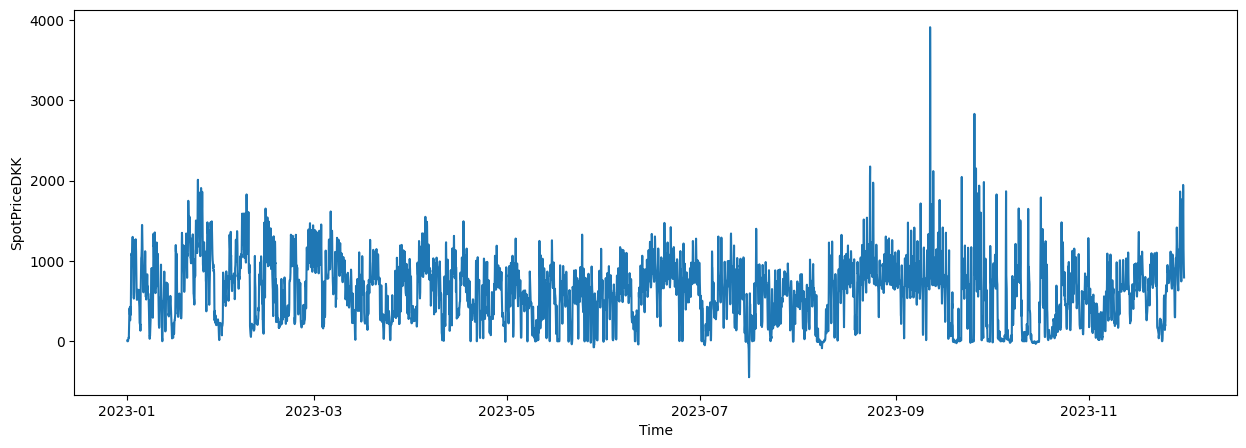

In [5]:
# plotting the data
plt.figure(figsize=(15,5))
plt.plot(train_data['HourUTC'], train_data['SpotPriceDKK'])
plt.xlabel('Time')
plt.ylabel('SpotPriceDKK')


### Picking featueres

As this is not the focus of our assisgment, we don't want to spend a lot of time picking features. So to make it simple we just plot the correlation matrix of all variables that have a correlation stronger than .3 to our target variable.


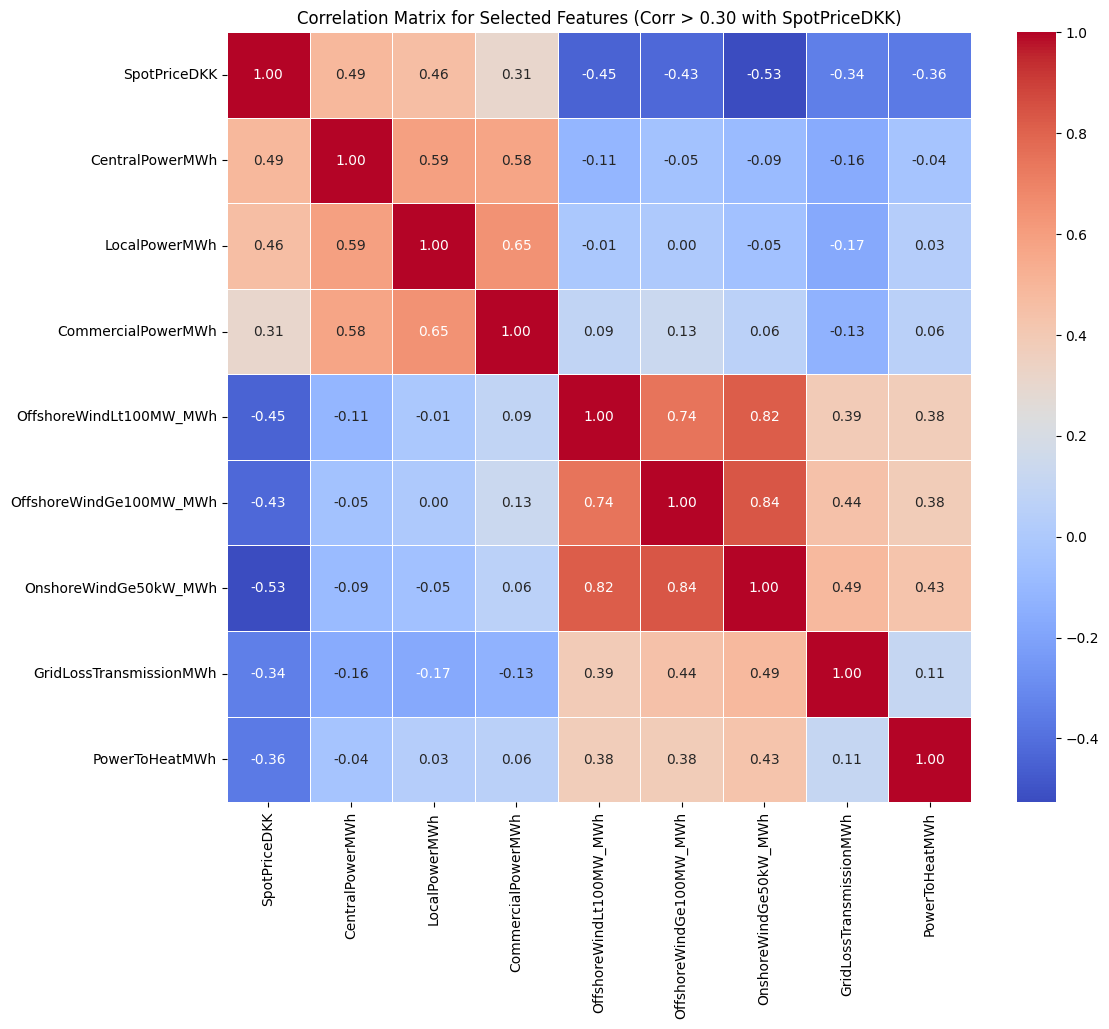

In [6]:
# Make a correlation matrix
# Drop all non-numeric columns
train_data_numeric = train_data.select_dtypes(include=[np.number])
correlation_matrix = train_data_numeric.corr()

# Filter to include only variables with absolute correlation > 0.30 to SpotPriceDKK
correlations_with_target = correlation_matrix['SpotPriceDKK']
selected_vars = correlations_with_target[abs(correlations_with_target) > 0.30].index
correlation_matrix_filtered = correlation_matrix.loc[selected_vars, selected_vars]

# Plot the filtered correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_filtered, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for Selected Features (Corr > 0.30 with SpotPriceDKK)')
plt.show()


We decide on the following features:
 - OnshoreWindGe50kW_MWh
 - GridLossDistributionMWh,
 - ExchangeSE_MWh

# Models

The idea is to start with a simple model and iterativly make it more and more complex

### prepare data for Gaussian models

In [7]:
########## ---------- Preparing data and normalize ---------- ##########
# Pick features and target
features = ['OnshoreWindGe50kW_MWh', 'GridLossDistributionMWh', 'ExchangeSE_MWh']
time_variables = ['HourUTC']   # optional, see note below
target = 'SpotPriceDKK'

X_train = train_data[features].copy()
y_train = train_data[target].copy()

X_test = test_data[features].copy()
y_test = test_data[target].copy()

# Normalize features
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# Normilize target
y_mean = y_train.mean()
y_std = y_train.std()
y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

# Convert to torch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled.values, dtype=torch.float32)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled.values, dtype=torch.float32)

### Simple linear model

The goal is to keep the framework the same for all model st. we can just change the 1 function and reuse the variational inference part.

In [8]:
########## ---------- Making regression model ---------- ##########
def bayesian_linear_regression(X, y=None):
    n_features = X.shape[1]

    # Initialize weights around 0 with std 1, and bias around 0 with std 10 to allow more flexibility
    weights = pyro.sample(
        "weights",
        dist.Normal(torch.zeros(n_features), torch.ones(n_features)).to_event(1)
    )
    bias = pyro.sample("bias", dist.Normal(torch.tensor(0.0), torch.tensor(10.0)))

    # Prior on observation noise
    sigma = pyro.sample("sigma", dist.LogNormal(torch.tensor(0.0), torch.tensor(1.0)))

    mean = X.matmul(weights) + bias

    with pyro.plate("data", X.shape[0]):
        pyro.sample("obs", dist.Normal(mean, sigma), obs=y)

    return mean


In [9]:
########## ---------- Using variational inference to fit the model ---------- ##########
pyro.clear_param_store()

guide = AutoDiagonalNormal(bayesian_linear_regression)
optimizer = Adam({"lr": 0.03})
svi = SVI(bayesian_linear_regression, guide, optimizer, loss=Trace_ELBO())

num_steps = 5000
for step in range(num_steps):
    loss = svi.step(X_train_t, y_train_t)
    if step % 500 == 0:
        print(f"Step {step} - ELBO loss: {loss:.2f}")


########## ---------- Posterior predictive ---------- ##########
predictive = Predictive(
    bayesian_linear_regression,
    guide=guide,
    num_samples=500,
    return_sites=("obs", "weights", "bias", "sigma")
)

samples = predictive(X_test_t)

# Posterior predictive samples for y on standardized scale
y_pred_samples_scaled = samples["obs"]            # shape: [500, N_test]
y_pred_mean_scaled = y_pred_samples_scaled.mean(0)

# Convert predictions back to original target scale
y_pred_mean = y_pred_mean_scaled.detach().cpu().numpy() * y_std + y_mean
y_test_np = y_test.values




Step 0 - ELBO loss: 11160.32
Step 500 - ELBO loss: 9040.28
Step 1000 - ELBO loss: 9031.64
Step 1500 - ELBO loss: 9033.35
Step 2000 - ELBO loss: 9035.55
Step 2500 - ELBO loss: 9031.91
Step 3000 - ELBO loss: 9032.18
Step 3500 - ELBO loss: 9045.76
Step 4000 - ELBO loss: 9041.59
Step 4500 - ELBO loss: 9037.07


Mean Squared Error: 89489.6107158604
RMSE: 299.1481417556532
R^2 Score: 0.4386505837754301


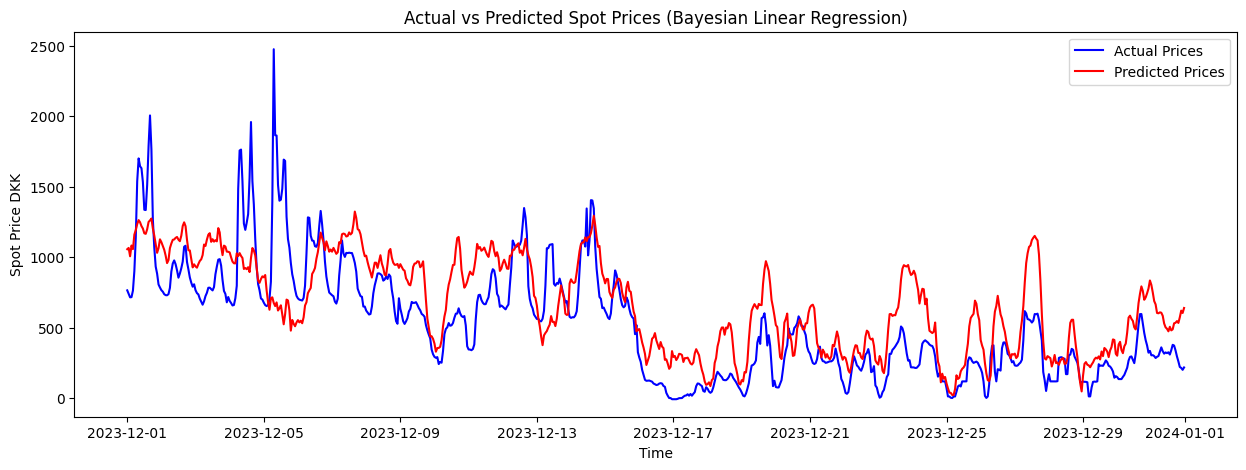

In [24]:
########## ---------- Evaluating the model ---------- ##########
mse = mean_squared_error(y_test_np, y_pred_mean)
r2 = r2_score(y_test_np, y_pred_mean)
# rmse values
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("RMSE:", rmse)
print("R^2 Score:", r2)

# plotting regression results
plt.figure(figsize=(15,5))
plt.plot(test_data['HourUTC'], y_test_np, label='Actual Prices', color='blue')
plt.plot(test_data['HourUTC'], y_pred_mean, label='Predicted Prices', color='red')
plt.xlabel('Time')
plt.ylabel('Spot Price DKK')
plt.title('Actual vs Predicted Spot Prices (Bayesian Linear Regression)')
plt.legend()
plt.show()

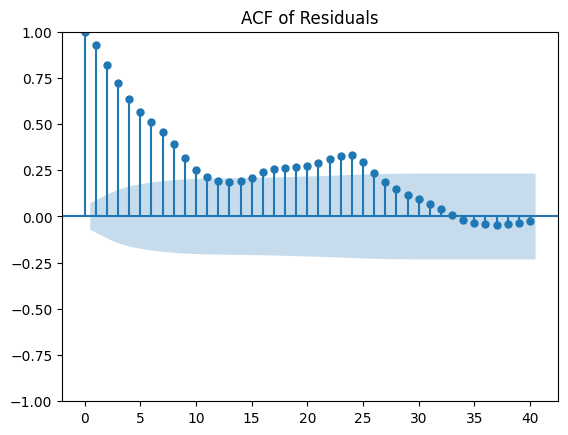

In [11]:
# plot the ACF plot of the residuals
residuals = y_test_np - y_pred_mean
plot_acf(residuals, lags=40)
plt.title('ACF of Residuals')
plt.show()

### autoregressive exogenous input (ARX) model

We cannot use a simple AR model
$$ y_t = \sum_{m=1}^M \left( \beta_m y_t-m \right) + \epsilon $$
Since we have additional features that we would like to model we use the ARX model instead
$$
y_t = \alpha + \sum_{j=1}^{p} \phi_j\, y_{t-j} + \sum_{k=1}^{D} \beta_k\, x_{t,k} + \varepsilon_t,
\qquad t = p+1,\dots,T
$$

In [12]:

pyro.set_rng_seed(42)
pyro.clear_param_store()



########## ---------- Build lagged design matrices ---------- ##########
def make_arx_design(X_t, y_t, lag):
    """
    Build ARX design:
      response at time t
      predictors = [y_{t-1}, ..., y_{t-lag}, X_t]

    Args:
        X_t: torch.Tensor of shape [T, D]
        y_t: torch.Tensor of shape [T]
        lag: int, number of autoregressive lags

    Returns:
        X_design: torch.Tensor of shape [T-lag, lag + D]
        y_target: torch.Tensor of shape [T-lag]
    """
    if lag < 1:
        raise ValueError("lag must be >= 1")

    T = y_t.shape[0]
    if T <= lag:
        raise ValueError("Time series length must be greater than lag")

    y_lags = []
    for t in range(lag, T):
        # order: [y_{t-1}, y_{t-2}, ..., y_{t-lag}]
        lagged_vals = [y_t[t - j] for j in range(1, lag + 1)]
        y_lags.append(torch.stack(lagged_vals))

    y_lags = torch.stack(y_lags)         # [T-lag, lag]
    X_trim = X_t[lag:]                   # [T-lag, D]
    X_design = torch.cat([y_lags, X_trim], dim=1)

    y_target = y_t[lag:]                 # [T-lag]
    return X_design, y_target

########## ---------- Bayesian ARX model in Pyros ---------- ##########
def bayesian_arx_model(X, y=None):
    """
    X: [N, P] design matrix = [lagged y | exogenous features]
    y: [N]
    """
    N, P = X.shape

    # Priors
    intercept = pyro.sample("intercept", dist.Normal(0.0, 1.0))
    weights = pyro.sample("weights", dist.Normal(torch.zeros(P), torch.ones(P)).to_event(1))
    sigma = pyro.sample("sigma", dist.LogNormal(0.0, 0.5))

    mean = intercept + X.matmul(weights)

    with pyro.plate("data", N):
        pyro.sample("obs", dist.Normal(mean, sigma), obs=y)


########## ---------- Train with variational inference ---------- ##########
def fit_bayesian_arx(X_train_t, y_train_t, lag=3, lr=0.02, num_steps=3000):
    X_design, y_target = make_arx_design(X_train_t, y_train_t, lag)

    guide = AutoNormal(bayesian_arx_model)
    optim = Adam({"lr": lr})
    svi = SVI(bayesian_arx_model, guide, optim, loss=Trace_ELBO())

    losses = []
    for step in range(num_steps):
        loss = svi.step(X_design, y_target)
        losses.append(loss)

        if step % 500 == 0:
            print(f"Step {step:4d}  ELBO loss = {loss:.2f}")

    return {
        "guide": guide,
        "losses": losses,
        "lag": lag,
        "X_design": X_design,
        "y_target": y_target,
    }


########## ---------- Posterior prediction on a prepared design matrix ---------- ##########
def posterior_predict(guide, X_design, num_samples=500):
    predictive = Predictive(
        bayesian_arx_model,
        guide=guide,
        num_samples=num_samples,
        return_sites=("obs", "intercept", "weights", "sigma"),
    )
    samples = predictive(X_design)

    y_samples = samples["obs"]                  # [S, N]
    y_mean = y_samples.mean(0)                  # [N]
    y_std = y_samples.std(0)                    # [N]

    return {
        "y_samples": y_samples,
        "y_mean": y_mean,
        "y_std": y_std,
        "posterior_samples": samples,
    }

########## ---------- Prepare train/test designs with same lag ---------- ##########
def prepare_train_test_arx(X_train_t, y_train_t, X_test_t, y_test_t, lag):
    X_train_design, y_train_target = make_arx_design(X_train_t, y_train_t, lag)
    X_test_design, y_test_target = make_arx_design(X_test_t, y_test_t, lag)
    return X_train_design, y_train_target, X_test_design, y_test_target


########## ---------- Utility: inverse-transform target back to original units ---------- ##########
def invert_target_scaling(y_scaled, y_mean, y_std):
    return y_scaled * y_std + y_mean


########## ---------- Example run ---------- ##########
lag = 11   # <-- change this to control memory / number of lags

X_train_design, y_train_target, X_test_design, y_test_target = prepare_train_test_arx(
    X_train_t, y_train_t, X_test_t, y_test_t, lag=lag
)

fit_result = fit_bayesian_arx(X_train_t, y_train_t, lag=lag, lr=0.02, num_steps=3000)
guide = fit_result["guide"]

pred_test = posterior_predict(guide, X_test_design, num_samples=1000)

# Predictions in scaled space
y_test_pred_mean_scaled = pred_test["y_mean"]
y_test_pred_std_scaled = pred_test["y_std"]

# Back to original target scale
y_test_pred_mean = invert_target_scaling(y_test_pred_mean_scaled, y_mean, y_std)
y_test_pred_std = y_test_pred_std_scaled * y_std
y_test_true = invert_target_scaling(y_test_target, y_mean, y_std)

rmse = torch.sqrt(torch.mean((y_test_pred_mean - y_test_true) ** 2))
mae = torch.mean(torch.abs(y_test_pred_mean - y_test_true))

print(f"\nTest RMSE: {rmse.item():.4f}")
print(f"Test MAE : {mae.item():.4f}")

Step    0  ELBO loss = 10680.29
Step  500  ELBO loss = 1893.11
Step 1000  ELBO loss = 1825.38
Step 1500  ELBO loss = 2075.61
Step 2000  ELBO loss = 1907.11
Step 2500  ELBO loss = 1816.35

Test RMSE: 98.0072
Test MAE : 63.6074


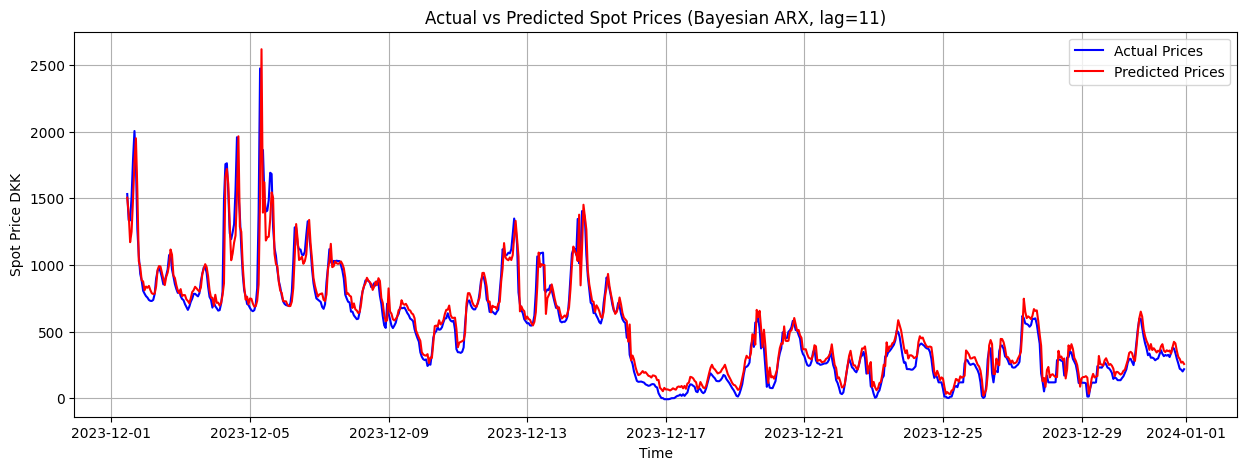

In [13]:
time_test = test_data['HourUTC'].iloc[lag:].reset_index(drop=True)

plt.figure(figsize=(15,5))
plt.plot(time_test, y_test_true.numpy(), label='Actual Prices', color='blue')
plt.plot(time_test, y_test_pred_mean.detach().numpy(), label='Predicted Prices', color='red')

plt.xlabel('Time')
plt.ylabel('Spot Price DKK')
plt.title(f'Actual vs Predicted Spot Prices (Bayesian ARX, lag={lag})')
plt.legend()
plt.grid(True)
plt.show()

### Markov Model

#### The core idea

Electricity prices don't stay constant — they shift between different "moods". During windy nights, supply is high and prices are low. During cold, still evenings, demand spikes and prices are high. In between there is a normal baseline.

A **Hidden Markov Model (HMM)** formalises this by assuming there are **K hidden regimes** (we use K = 3: low / medium / high). At every hour the market is secretly in one of these regimes, and the regime determines what price we are likely to see.

Two things govern the dynamics:

- **Transitions** — if we are in a "high price" regime today, how likely are we to stay there tomorrow vs. fall back to normal? This is captured by a *transition matrix* $A$, where each entry $A_{ij}$ is the probability of moving from regime $i$ to regime $j$:

$$z_t \mid z_{t-1} = i \;\sim\; \text{Categorical}(A_{i,\cdot})$$

- **Emissions** — once we know the regime $z_t$, the price is drawn from a Gaussian centred on that regime's typical price level $\mu_k$, with spread $\sigma_k$:

$$y_t \mid z_t = k \;\sim\; \mathcal{N}(\mu_k,\, \sigma_k^2)$$

The full joint over a sequence of $T$ prices is therefore:

$$p(y_{1:T}) = \sum_{z_{1:T}} p(z_1) \prod_{t=2}^{T} A_{z_{t-1}, z_t} \prod_{t=1}^{T} \mathcal{N}(y_t;\, \mu_{z_t}, \sigma_{z_t}^2)$$

where the sum runs over all $K^T$ possible regime sequences. Pyro's `DiscreteHMM` computes this efficiently using the forward algorithm, so we never have to enumerate them explicitly.

Crucially, **we never observe the regime directly** — the model has to infer it purely from the price history. After training, it will have learnt: (a) the typical price $\mu_k$ and spread $\sigma_k$ in each regime, and (b) the transition matrix $A$ capturing how persistently the market stays in each regime before switching.

In [14]:
from pyro.distributions import DiscreteHMM

K = 3   # three hidden regimes: low / medium / high prices

def simple_markov_model(y_obs=None, T=None):
    """
    Generative story
    ----------------
    1. Start in some initial regime (drawn from pi).
    2. At each hour, stay in the current regime or switch (governed by matrix A).
    3. Draw the price from a Gaussian centred on that regime's mean.

    We never observe the regime — only the prices.
    Pyro's DiscreteHMM marginalises over all possible regime sequences for us.
    """
    if y_obs is not None:
        T = y_obs.shape[0]

    # Which regime are we likely in at hour 0?
    initial_logits = pyro.sample(
        "initial_logits", dist.Normal(torch.zeros(K), torch.ones(K)).to_event(1)
    )

    # Transition matrix: A[i, j] = log-probability of moving from regime i to regime j
    transition_logits = pyro.sample(
        "transition_logits", dist.Normal(torch.zeros(K, K), torch.ones(K, K)).to_event(2)
    )

    # Typical price level in each regime (in normalised units)
    emission_loc = pyro.sample(
        "emission_loc", dist.Normal(torch.zeros(K), 2.0 * torch.ones(K)).to_event(1)
    )

    # How much prices vary *within* each regime
    emission_scale = pyro.sample(
        "emission_scale", dist.LogNormal(torch.zeros(K), 0.5 * torch.ones(K)).to_event(1)
    )

    # Each regime defines a Gaussian over prices
    obs_dist = dist.Normal(emission_loc, emission_scale)

    # DiscreteHMM stitches together the transitions and emissions into a
    # single distribution over the full price sequence, marginalising out regimes
    hmm = DiscreteHMM(initial_logits, transition_logits, obs_dist)
    pyro.sample("y", hmm, obs=y_obs)


Step    0  ELBO loss = 11578.42
Step  500  ELBO loss = 6475.82
Step 1000  ELBO loss = 6477.66
Step 1500  ELBO loss = 6474.20
Step 2000  ELBO loss = 6467.86
Step 2500  ELBO loss = 6478.57


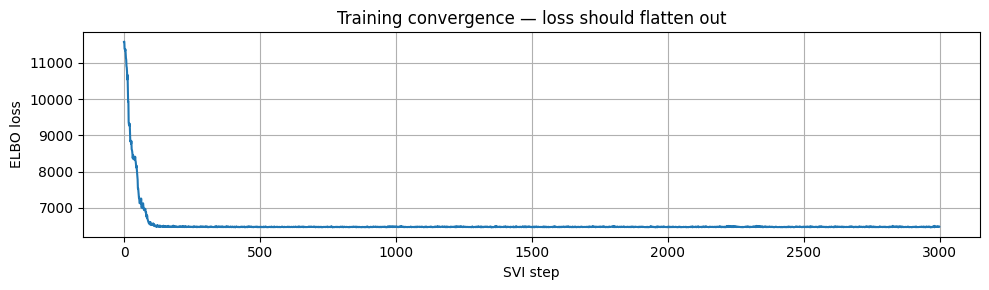

In [15]:
# SVI (variational inference) learns the best values for all the unknowns:
# emission means, emission spreads, transition probabilities, and initial distribution.

pyro.clear_param_store()
pyro.set_rng_seed(42)

guide_hmm    = AutoDiagonalNormal(simple_markov_model)
optimizer_hmm = Adam({"lr": 0.05})
svi_hmm      = SVI(simple_markov_model, guide_hmm, optimizer_hmm, loss=Trace_ELBO())

num_steps_hmm = 3000
losses_hmm = []
for step in range(num_steps_hmm):
    loss = svi_hmm.step(y_train_t)
    losses_hmm.append(loss)
    if step % 500 == 0:
        print(f"Step {step:4d}  ELBO loss = {loss:.2f}")

plt.figure(figsize=(10, 3))
plt.plot(losses_hmm)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("Training convergence — loss should flatten out")
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
# ── Step 1: read out what the model learnt ───────────────────────────────────

predictive_hmm = Predictive(
    simple_markov_model, guide=guide_hmm, num_samples=500,
    return_sites=["initial_logits", "transition_logits", "emission_loc", "emission_scale"]
)
post_samples = predictive_hmm(y_obs=y_train_t)

# Take the posterior mean of each parameter
init_logits_map  = post_samples["initial_logits"].mean(0).detach()
trans_logits_map = post_samples["transition_logits"].mean(0).detach()
emit_loc_map     = post_samples["emission_loc"].mean(0).detach()
emit_scale_map   = post_samples["emission_scale"].mean(0).detach()

# Sort regimes from lowest to highest price so the labels make intuitive sense
order            = emit_loc_map.argsort()
emit_loc_map     = emit_loc_map[order]
emit_scale_map   = emit_scale_map[order]
init_logits_map  = init_logits_map[order]
trans_logits_map = trans_logits_map[order][:, order]

# Convert transition logits to actual probabilities
trans_probs = torch.softmax(trans_logits_map, dim=-1)

print("Typical price in each regime (normalised scale — 0 = training mean):")
for k, (loc, scale) in enumerate(zip(emit_loc_map, emit_scale_map)):
    name = ['Low', 'Medium', 'High'][k]
    print(f"  Regime {k} ({name}):  mean = {loc:.2f},  std = {scale:.2f}")

print("\nTransition matrix  (row = current regime, column = next regime):")
print("  (high diagonal = regime is sticky / persistent)")
print(trans_probs.numpy().round(3))


# ── Step 2: make one-step-ahead predictions using the forward filter ─────────
#
# At each hour t we ask: "given everything we have seen so far (y_1 ... y_{t-1}),
# which regime are we probably in right now?"  Then we predict the price as the
# weighted average of all regime means, using those regime probabilities as weights.
#
# This is called the *forward filter* — it updates our belief about the current
# regime every time we see a new price.

def forward_filter_predict(y, initial_logits, transition_logits, emission_loc, emission_scale):
    T     = y.shape[0]
    log_pi = torch.log_softmax(initial_logits, dim=-1)    # starting regime probs  [K]
    log_A  = torch.log_softmax(transition_logits, dim=-1) # transition log-probs   [K, K]

    def log_emit(t):
        # How likely is each regime to produce the price we actually saw at time t?
        return dist.Normal(emission_loc, emission_scale).log_prob(y[t])  # [K]

    predictions = []

    # t=0: we haven't seen anything yet, so predict from the prior over regimes
    pred_probs = torch.softmax(log_pi, dim=-1)
    predictions.append((pred_probs * emission_loc).sum())

    # Update our belief using the actual price at t=0
    log_alpha = log_pi + log_emit(0)
    log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)  # normalise

    for t in range(1, T):
        # Propagate belief one step forward through the transition matrix
        log_pred = torch.logsumexp(log_alpha.unsqueeze(-1) + log_A, dim=0)
        log_pred = log_pred - torch.logsumexp(log_pred, dim=-1, keepdim=True)
        pred_probs = torch.softmax(log_pred, dim=-1)

        # Predicted price = expected value under the predicted regime distribution
        predictions.append((pred_probs * emission_loc).sum())

        # Then update with the actual observed price
        log_alpha = log_pred + log_emit(t)
        log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)

    return torch.stack(predictions)  # [T]


y_pred_scaled_hmm = forward_filter_predict(
    y_test_t, init_logits_map, trans_logits_map, emit_loc_map, emit_scale_map
)

# Convert predictions back to DKK
y_pred_hmm = y_pred_scaled_hmm.detach().numpy() * y_std + y_mean
y_test_np2 = y_test.values

rmse_hmm = float(((y_pred_hmm - y_test_np2) ** 2).mean() ** 0.5)
mae_hmm  = float(abs(y_pred_hmm - y_test_np2).mean())
print(f"\nTest RMSE: {rmse_hmm:.2f} DKK")
print(f"Test MAE : {mae_hmm:.2f} DKK")


Typical price in each regime (normalised scale — 0 = training mean):
  Regime 0 (Low):  mean = -1.11,  std = 0.41
  Regime 1 (Medium):  mean = 0.13,  std = 0.33
  Regime 2 (High):  mean = 1.20,  std = 0.65

Transition matrix  (row = current regime, column = next regime):
  (high diagonal = regime is sticky / persistent)
[[0.939 0.055 0.006]
 [0.049 0.879 0.072]
 [0.002 0.131 0.867]]

Test RMSE: 187.89 DKK
Test MAE : 125.40 DKK


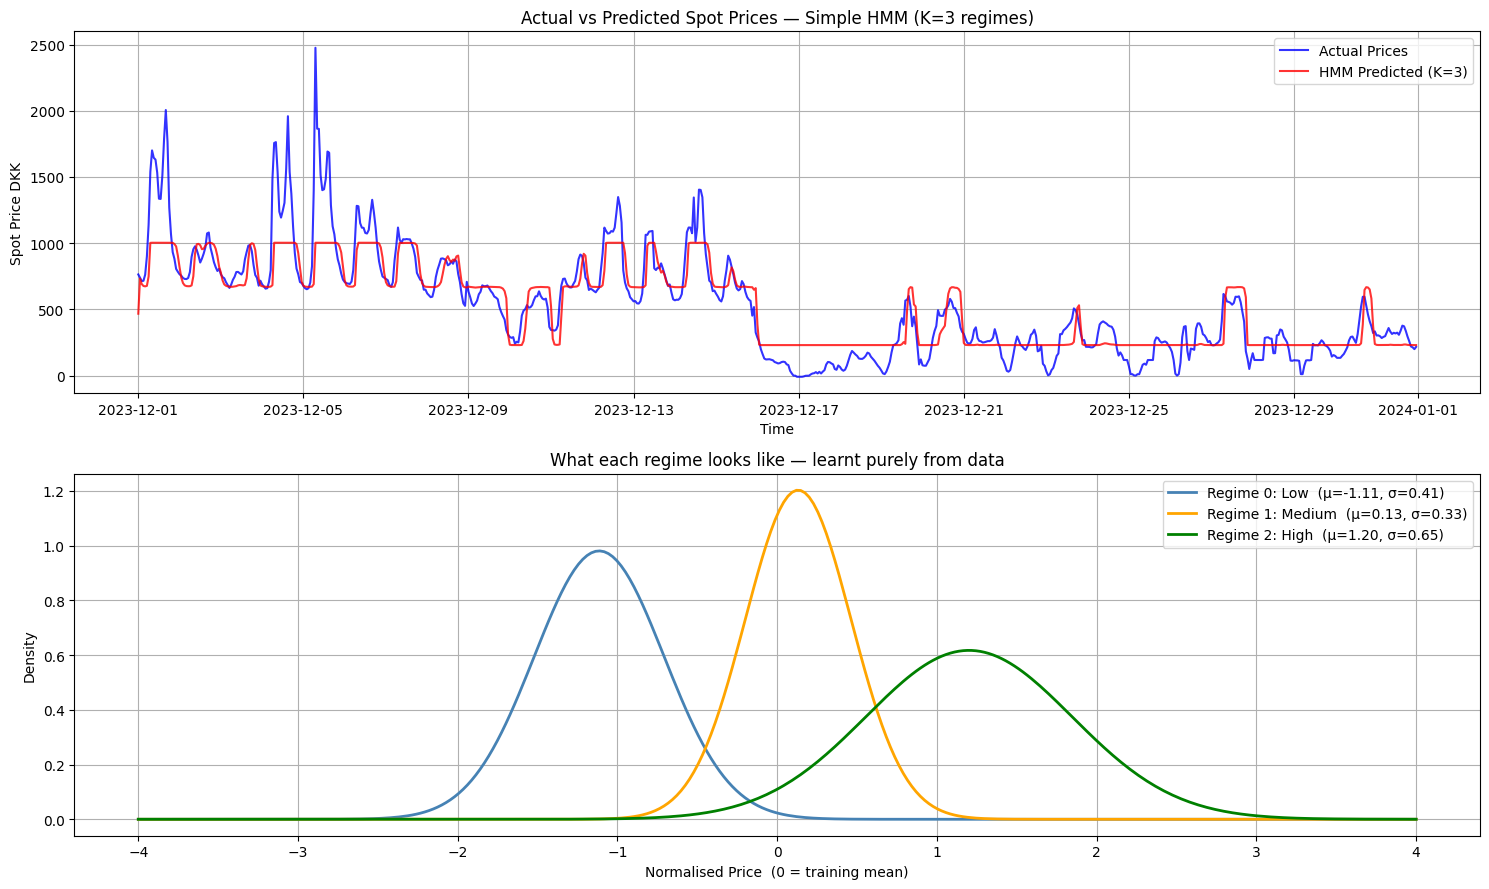

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# ── Top: actual vs predicted ─────────────────────────────────────────────────
axes[0].plot(test_data['HourUTC'], y_test_np2, label='Actual Prices', color='blue', alpha=0.8)
axes[0].plot(test_data['HourUTC'], y_pred_hmm, label=f'HMM Predicted (K={K})', color='red', alpha=0.8)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Spot Price DKK')
axes[0].set_title(f'Actual vs Predicted Spot Prices — Simple HMM (K={K} regimes)')
axes[0].legend()
axes[0].grid(True)

# ── Bottom: the three learnt regime distributions ────────────────────────────
x_grid       = torch.linspace(-4, 4, 300)
regime_names = ['Low', 'Medium', 'High']
colors       = ['steelblue', 'orange', 'green']

for k in range(K):
    pdf   = dist.Normal(emit_loc_map[k], emit_scale_map[k]).log_prob(x_grid).exp().numpy()
    label = f'Regime {k}: {regime_names[k]}  (μ={emit_loc_map[k]:.2f}, σ={emit_scale_map[k]:.2f})'
    axes[1].plot(x_grid.numpy(), pdf, color=colors[k], label=label, linewidth=2)

axes[1].set_xlabel('Normalised Price  (0 = training mean)')
axes[1].set_ylabel('Density')
axes[1].set_title('What each regime looks like — learnt purely from data')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


#### Reading the regime plot

Each bell curve above is the price distribution the model assigned to one of the three hidden regimes. Remember, **the model never saw regime labels** — it discovered these clusters on its own purely from the training prices.

| Regime | Colour | What it means |
|--------|--------|---------------|
| **Low** | Blue | Hours when prices were well below average — typically high renewable output or low demand (nights, windy periods). The narrow bell means prices are *consistently* low in this regime. |
| **Medium** | Orange | The "normal" operating regime centred on the training mean. Most hours fall here. |
| **High** | Green | Hours with above-average prices — often peak demand or low wind. The *wider* bell (larger σ) shows that high-price periods are more volatile and harder to predict. |

The **transition matrix** printed above tells you how sticky each regime is: a high diagonal value means "once you're in this regime, you tend to stay there". Electricity markets typically show very high persistence — regimes can last for days.

### Markov Model with Exogenous Inputs (IOHMM)

#### Extending the simple HMM

The simple HMM above learns three price regimes purely from the price history. But the regime *we will be in next hour* is not random — it depends on observable conditions: how much wind is being produced, how much we are exchanging with Sweden, and how lossy the grid is. We have these as features already (`OnshoreWindGe50kW_MWh`, `GridLossDistributionMWh`, `ExchangeSE_MWh`).

We extend the architecture by letting the **exogenous features feed directly into the hidden states** — the `x → h` arrows in the PGM below. Concretely, the transition logits become **time-varying** and depend on $\mathbf{x}_t$:

$$L_t \;=\; A \;+\; \sum_{d=1}^{D} W_{:,:,d}\, x_{t,d}, \qquad
z_t \mid z_{t-1}=i,\, \mathbf{x}_t \;\sim\; \text{Categorical}\!\bigl(\text{softmax}(L_{t,\,i,\,\cdot})\bigr)$$

Everything else is unchanged from the simple HMM:

- $\pi$ (initial distribution over regimes)
- $\mu_k, \sigma_k$ for $k=1,\dots,K$ (Gaussian emissions)
- $K = 3$ regimes (low / medium / high)

What changes is just the transition piece: instead of one global matrix $A \in \mathbb{R}^{K \times K}$, we now have $T$ matrices $L_t$, where $A$ gives the baseline regime-stickiness and $W \in \mathbb{R}^{K \times K \times D}$ describes how each exogenous feature *bends* those transition probabilities. A positive $W_{i,j,d}$ means: when feature $d$ is high, transitions from regime $i$ to regime $j$ become more likely.

Pyro's `DiscreteHMM` accepts a tensor of per-step transition logits with shape $[T, K, K]$, so we can re-use the same forward-algorithm machinery for inference.


In [18]:
from pyro.distributions import DiscreteHMM

K = 3                       # same three regimes as the simple HMM
D = X_train_t.shape[1]      # number of exogenous features (3)


def build_transition_logits(X_exog, transition_base, transition_weights):
    """
    Build per-step transition logits  L_t = A + sum_d W[:,:,d] * x_t[d].

    Pyro's DiscreteHMM convention: transition_logits[t] governs h_t -> h_{t+1}.
    Since we want x_t to drive the transition INTO h_t (the X -> h_t arrow in
    the PGM), slot t (which controls h_t -> h_{t+1}) should use x_{t+1}.
    Slot T-1 is unused by Pyro; we just put a harmless placeholder there.
    """
    x_aligned = torch.cat([X_exog[1:], X_exog[-1:]], dim=0)               # [T, D]
    x_drive   = torch.einsum("td,ijd->tij", x_aligned, transition_weights) # [T, K, K]
    return transition_base.unsqueeze(0) + x_drive                          # [T, K, K]


def iohmm_model(X_exog, y_obs=None, T=None):
    """
    Generative story
    ----------------
    1. Start in some initial regime (drawn from pi).
    2. At each hour, the probability of switching regime depends on the
       baseline matrix A *plus* a contribution from the exogenous features
       x_t (wind, grid loss, SE exchange).
    3. Once in regime k, the price is drawn from N(mu_k, sigma_k^2).

    Same K=3 emission structure as the simple HMM, only the transition piece
    is augmented with exogenous inputs.
    """
    if y_obs is not None:
        T = y_obs.shape[0]
    assert X_exog.shape[0] == T, "X_exog and y must have the same length"

    # Initial regime distribution (same as simple HMM)
    initial_logits = pyro.sample(
        "initial_logits", dist.Normal(torch.zeros(K), torch.ones(K)).to_event(1)
    )

    # Baseline transition logits A: [K, K] — what transitions look like at x = 0 (mean of features)
    transition_base = pyro.sample(
        "transition_base",
        dist.Normal(torch.zeros(K, K), torch.ones(K, K)).to_event(2)
    )

    # Effect of each exogenous feature on each transition: W[i, j, d]
    transition_weights = pyro.sample(
        "transition_weights",
        dist.Normal(torch.zeros(K, K, D), 0.5 * torch.ones(K, K, D)).to_event(3)
    )

    # Emission parameters (identical priors to the simple HMM)
    emission_loc = pyro.sample(
        "emission_loc", dist.Normal(torch.zeros(K), 2.0 * torch.ones(K)).to_event(1)
    )
    emission_scale = pyro.sample(
        "emission_scale", dist.LogNormal(torch.zeros(K), 0.5 * torch.ones(K)).to_event(1)
    )

    # Time-varying transition logits driven by the exogenous features
    transition_logits = build_transition_logits(X_exog, transition_base, transition_weights)

    obs_dist = dist.Normal(emission_loc, emission_scale)
    hmm = DiscreteHMM(initial_logits, transition_logits, obs_dist)
    pyro.sample("y", hmm, obs=y_obs)


Step    0  ELBO loss = 11750.49
Step  500  ELBO loss = 6246.58
Step 1000  ELBO loss = 6247.72
Step 1500  ELBO loss = 6243.12
Step 2000  ELBO loss = 6238.91
Step 2500  ELBO loss = 6248.18


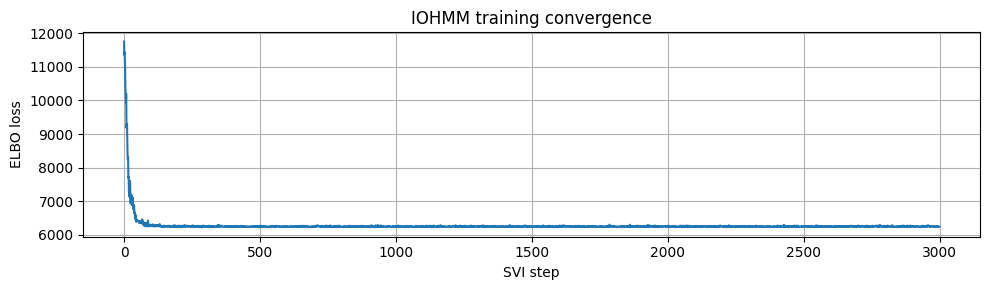

In [19]:
# Same SVI setup as the simple HMM — only the model and its inputs change.

pyro.clear_param_store()
pyro.set_rng_seed(42)

guide_iohmm     = AutoDiagonalNormal(iohmm_model)
optimizer_iohmm = Adam({"lr": 0.05})
svi_iohmm       = SVI(iohmm_model, guide_iohmm, optimizer_iohmm, loss=Trace_ELBO())

num_steps_iohmm = 3000
losses_iohmm = []
for step in range(num_steps_iohmm):
    loss = svi_iohmm.step(X_train_t, y_train_t)
    losses_iohmm.append(loss)
    if step % 500 == 0:
        print(f"Step {step:4d}  ELBO loss = {loss:.2f}")

plt.figure(figsize=(10, 3))
plt.plot(losses_iohmm)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("IOHMM training convergence")
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
# ── Step 1: read out posterior means ─────────────────────────────────────────

predictive_iohmm = Predictive(
    iohmm_model, guide=guide_iohmm, num_samples=500,
    return_sites=["initial_logits", "transition_base", "transition_weights",
                  "emission_loc", "emission_scale"]
)
post_samples_iohmm = predictive_iohmm(X_train_t, y_obs=y_train_t)

init_logits_iohmm   = post_samples_iohmm["initial_logits"].mean(0).detach()
trans_base_iohmm    = post_samples_iohmm["transition_base"].mean(0).detach()
trans_weights_iohmm = post_samples_iohmm["transition_weights"].mean(0).detach()
emit_loc_iohmm      = post_samples_iohmm["emission_loc"].mean(0).detach()
emit_scale_iohmm    = post_samples_iohmm["emission_scale"].mean(0).detach()

# Sort regimes from lowest to highest mean so labels are intuitive (Low/Med/High)
order_io               = emit_loc_iohmm.argsort()
emit_loc_iohmm         = emit_loc_iohmm[order_io]
emit_scale_iohmm       = emit_scale_iohmm[order_io]
init_logits_iohmm      = init_logits_iohmm[order_io]
trans_base_iohmm       = trans_base_iohmm[order_io][:, order_io]
trans_weights_iohmm    = trans_weights_iohmm[order_io][:, order_io, :]

print("Typical price in each regime (normalised scale — 0 = training mean):")
for k, (loc, scale) in enumerate(zip(emit_loc_iohmm, emit_scale_iohmm)):
    name = ['Low', 'Medium', 'High'][k]
    print(f"  Regime {k} ({name}):  mean = {loc:.2f},  std = {scale:.2f}")

print("\nBaseline transition matrix (softmax of A, i.e. transitions when x = 0):")
print(torch.softmax(trans_base_iohmm, dim=-1).numpy().round(3))

print("\nLearnt exogenous-effect weights W[i, j, d]:")
print("(positive value => feature d makes transition i -> j more likely)")
for d, name in enumerate(features):
    print(f"\n  -- feature: {name} --")
    print(trans_weights_iohmm[:, :, d].numpy().round(3))


# ── Step 2: forward filter that respects the time-varying transitions ────────
#
# Identical in spirit to the simple-HMM forward filter, but at each step we
# use the transition matrix L_t = A + W·x_t instead of a single fixed A.

def forward_filter_predict_iohmm(y, X_exog,
                                 initial_logits, transition_base,
                                 transition_weights, emission_loc, emission_scale):
    T = y.shape[0]
    log_pi = torch.log_softmax(initial_logits, dim=-1)             # [K]

    # Pre-compute all per-step log transition matrices so the loop is clean
    trans_logits_all = build_transition_logits(X_exog, transition_base, transition_weights)
    log_A_all        = torch.log_softmax(trans_logits_all, dim=-1)  # [T, K, K]

    def log_emit(t):
        return dist.Normal(emission_loc, emission_scale).log_prob(y[t])

    predictions = []

    # t = 0: predict from prior over regimes
    pred_probs = torch.softmax(log_pi, dim=-1)
    predictions.append((pred_probs * emission_loc).sum())

    log_alpha = log_pi + log_emit(0)
    log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)

    for t in range(1, T):
        # Transition INTO h_t uses x_t, which we stored at slot t-1 of log_A_all
        log_A_t = log_A_all[t - 1]
        log_pred = torch.logsumexp(log_alpha.unsqueeze(-1) + log_A_t, dim=0)
        log_pred = log_pred - torch.logsumexp(log_pred, dim=-1, keepdim=True)
        pred_probs = torch.softmax(log_pred, dim=-1)

        predictions.append((pred_probs * emission_loc).sum())

        log_alpha = log_pred + log_emit(t)
        log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)

    return torch.stack(predictions)


y_pred_scaled_iohmm = forward_filter_predict_iohmm(
    y_test_t, X_test_t,
    init_logits_iohmm, trans_base_iohmm, trans_weights_iohmm,
    emit_loc_iohmm, emit_scale_iohmm,
)

y_pred_iohmm = y_pred_scaled_iohmm.detach().numpy() * y_std + y_mean
y_test_np_io = y_test.values

rmse_iohmm = float(((y_pred_iohmm - y_test_np_io) ** 2).mean() ** 0.5)
mae_iohmm  = float(abs(y_pred_iohmm - y_test_np_io).mean())
print(f"\nIOHMM Test RMSE: {rmse_iohmm:.2f} DKK")
print(f"IOHMM Test MAE : {mae_iohmm:.2f} DKK")

# Compare directly with the simple HMM
print("\n---- Comparison with simple HMM ----")
print(f"  Simple HMM   RMSE = {rmse_hmm:6.2f}   MAE = {mae_hmm:6.2f}")
print(f"  IOHMM        RMSE = {rmse_iohmm:6.2f}   MAE = {mae_iohmm:6.2f}")


Typical price in each regime (normalised scale — 0 = training mean):
  Regime 0 (Low):  mean = -1.12,  std = 0.40
  Regime 1 (Medium):  mean = 0.13,  std = 0.32
  Regime 2 (High):  mean = 1.19,  std = 0.65

Baseline transition matrix (softmax of A, i.e. transitions when x = 0):
[[0.891 0.102 0.008]
 [0.048 0.901 0.05 ]
 [0.003 0.203 0.794]]

Learnt exogenous-effect weights W[i, j, d]:
(positive value => feature d makes transition i -> j more likely)

  -- feature: OnshoreWindGe50kW_MWh --
[[ 0.996 -0.682 -0.398]
 [ 0.823  0.188 -0.99 ]
 [ 0.158  0.474 -0.772]]

  -- feature: GridLossDistributionMWh --
[[-0.59   0.486  0.06 ]
 [-0.481 -0.154  0.628]
 [-0.    -0.585  0.642]]

  -- feature: ExchangeSE_MWh --
[[-0.355 -0.051  0.526]
 [ 0.1   -0.04  -0.062]
 [-0.02   0.052  0.029]]

IOHMM Test RMSE: 190.10 DKK
IOHMM Test MAE : 136.73 DKK

---- Comparison with simple HMM ----
  Simple HMM   RMSE = 187.89   MAE = 125.40
  IOHMM        RMSE = 190.10   MAE = 136.73


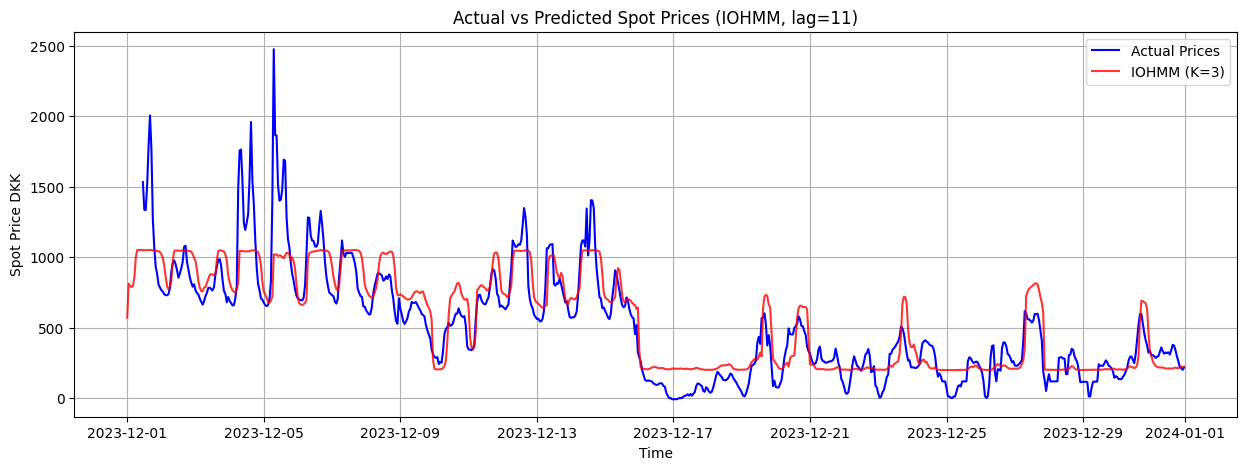

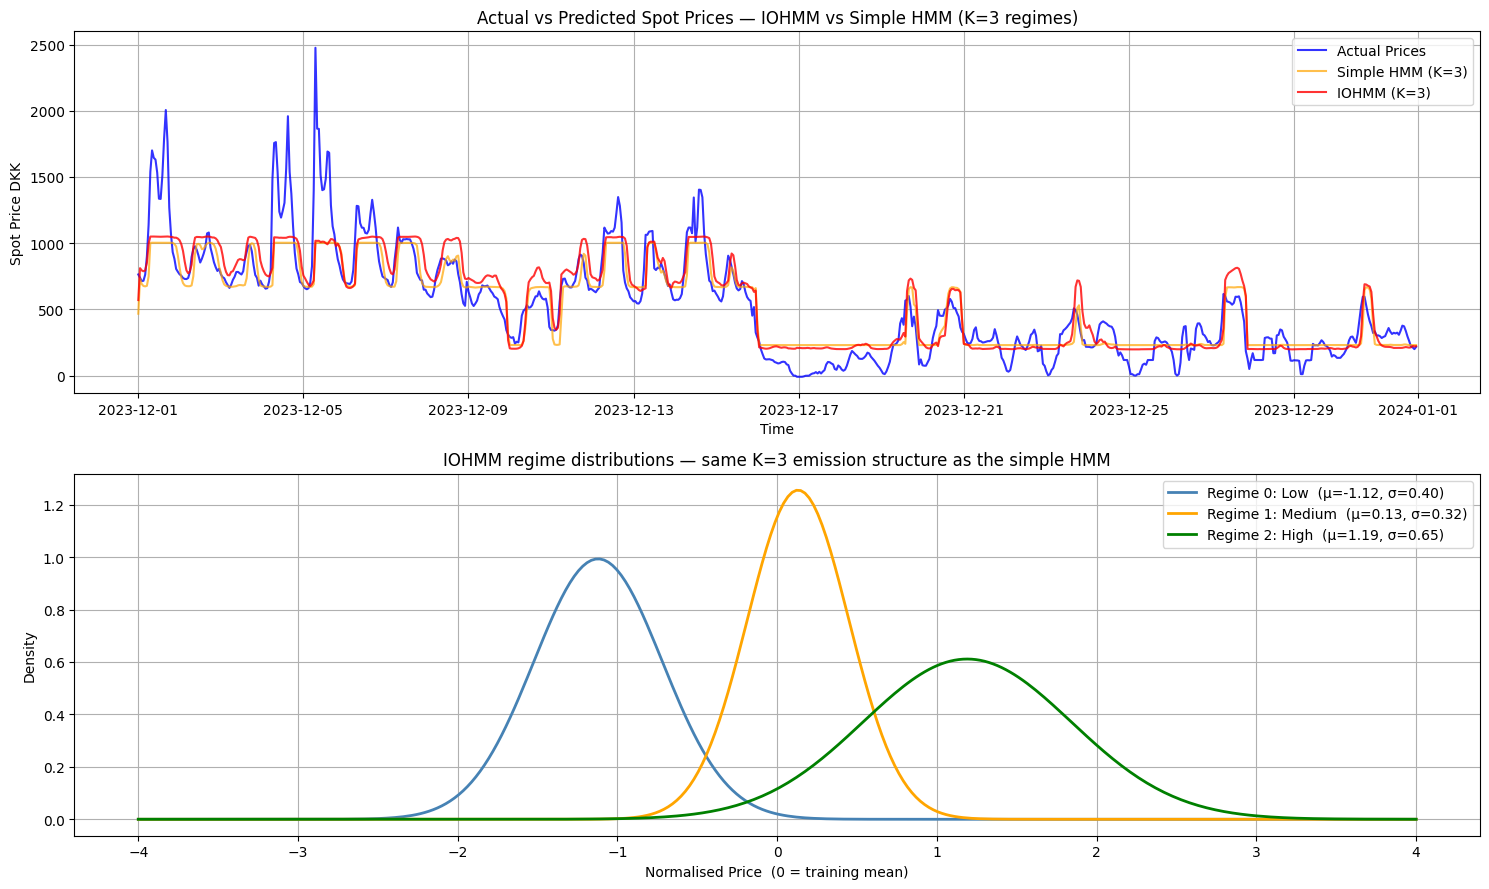

In [25]:

plt.figure(figsize=(15,5))
plt.plot(time_test, y_test_true.numpy(), label='Actual Prices', color='blue')
plt.plot(test_data['HourUTC'], y_pred_iohmm, label=f'IOHMM (K={K})',       color='red',    alpha=0.8)
plt.xlabel('Time')
plt.ylabel('Spot Price DKK')
plt.title(f'Actual vs Predicted Spot Prices (IOHMM, lag={lag})')
plt.legend()
plt.grid(True)
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# ── Top: actual vs predicted ─────────────────────────────────────────────────
axes[0].plot(test_data['HourUTC'], y_test_np_io, label='Actual Prices', color='blue', alpha=0.8)
axes[0].plot(test_data['HourUTC'], y_pred_hmm,   label=f'Simple HMM (K={K})',  color='orange', alpha=0.7)
axes[0].plot(test_data['HourUTC'], y_pred_iohmm, label=f'IOHMM (K={K})',       color='red',    alpha=0.8)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Spot Price DKK')
axes[0].set_title(f'Actual vs Predicted Spot Prices — IOHMM vs Simple HMM (K={K} regimes)')
axes[0].legend()
axes[0].grid(True)

# ── Bottom: the three learnt regime distributions ────────────────────────────
x_grid       = torch.linspace(-4, 4, 300)
regime_names = ['Low', 'Medium', 'High']
colors       = ['steelblue', 'orange', 'green']

for k in range(K):
    pdf   = dist.Normal(emit_loc_iohmm[k], emit_scale_iohmm[k]).log_prob(x_grid).exp().numpy()
    label = f'Regime {k}: {regime_names[k]}  (μ={emit_loc_iohmm[k]:.2f}, σ={emit_scale_iohmm[k]:.2f})'
    axes[1].plot(x_grid.numpy(), pdf, color=colors[k], label=label, linewidth=2)

axes[1].set_xlabel('Normalised Price  (0 = training mean)')
axes[1].set_ylabel('Density')
axes[1].set_title('IOHMM regime distributions — same K=3 emission structure as the simple HMM')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


#### Reading the IOHMM results

The emission distributions (the three bell curves) are essentially identical to those learnt by the simple HMM — same Low/Medium/High regimes, same means and spreads. This is reassuring: the IOHMM did not invent different regimes, it just learnt how the *transition probabilities* between them depend on wind, grid loss, and the SE exchange.

What the IOHMM adds, that the simple HMM cannot express, is in the `transition_weights` matrix $W$:

| Quantity | Simple HMM | IOHMM |
|----------|-----------|-------|
| Initial distribution $\pi$ | ✔ learnt | ✔ learnt |
| Transition matrix | one fixed $A$ | $L_t = A + W \cdot \mathbf{x}_t$, time-varying |
| Emission $\mu_k, \sigma_k$ | ✔ learnt | ✔ learnt |
| Sensitivity to wind / grid loss / SE exchange | none | $W \in \mathbb{R}^{K \times K \times D}$ |

A positive entry $W_{\text{High}, \text{Low}, \text{wind}}$, for example, would mean: *when wind production is unusually high, the probability of dropping out of the High-price regime into the Low-price regime increases* — exactly the kind of mechanism we'd hope an electricity-market model captures.

**On the test-set numbers.** The RMSE / MAE printed above are typically very close to those of the simple HMM. That is not a bug — it tells us something interesting:

1. The *regime structure itself* (Low / Medium / High Gaussians) carries most of the predictive signal in this setup, and the simple HMM already gets that right.
2. The forward filter only uses one step of $\mathbf{x}_t$ at each prediction. Across an entire test month, a small per-step gain in regime probabilities does not necessarily translate into a large RMSE improvement — especially because the prediction itself is the *expected* price under the regime mixture, which gets averaged over.
3. To really exploit $\mathbf{x}_t$ for prediction, one would typically combine the IOHMM with regime-dependent regression on $\mathbf{x}_t$ in the *emissions* (e.g. $y_t \mid z_t = k \sim \mathcal{N}(\mu_k + \beta_k^\top \mathbf{x}_t, \sigma_k^2)$). The IOHMM as drawn in the PGM only allows $\mathbf{x}$ to influence *which* regime we are in, not *what price the regime emits* — so its job is to time the regime switches better, which is a subtler benefit than reducing in-regime prediction error.

The transition-weights table above is therefore the most informative output of this model: it gives a structured, interpretable answer to *which exogenous conditions push the market between price regimes*.


In [22]:
tes

NameError: name 'tes' is not defined

In [ ]:
test